## Lunar DEMs

Notebook for loading and visualizing Lunar DEMs

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pylupnt as pnt
import os
from PIL import Image
Image.MAX_IMAGE_PIXELS = 1000000000 
figures_path = "../figures_IEEE/"

# autoreload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading from file

Files are available to download from https://pgda.gsfc.nasa.gov/products/54

The following code loads DEMs in `.JP2` file format and converts them into numpy array. 

In [2]:
# Read img using PIL Image
tile_name = 'SLDEM2015_256_60S_0S_120_240'
path = pnt.get_file_path(f"{tile_name}.JP2")
img = Image.open(path)  # TODO: change path to file if necesary
img.size

(30720, 15360)

In [ ]:
# Convert to numpy array (takes around 1m 30s)
img_np = np.array(img)

Loading directly from `.npy` file (much faster)

In [3]:
img_np = np.load(pnt.get_file_path(f"{tile_name}.npy"))

## 2D visualization

Plot a downsampled version of the DEM

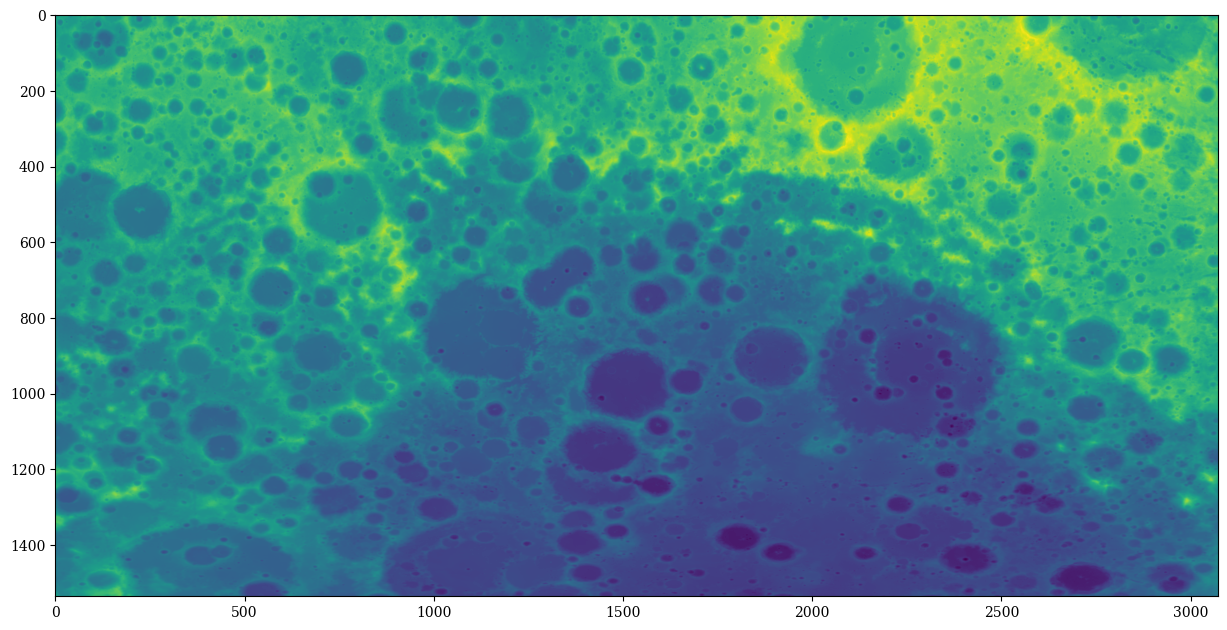

In [4]:
ds_factor = 10
img_np_ds = img_np[::ds_factor, ::ds_factor]
fig = plt.figure(figsize=(15, 30))
plt.imshow(img_np_ds)
plt.show()

## 3D visualization

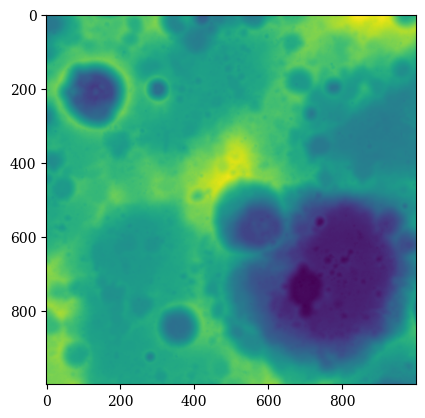

In [5]:
# Look at 1000x1000 patch in the top left corner
patch = img_np[:1000, :1000]
Z = patch

# Display the image
plt.imshow(patch)
plt.show()

For tile `SLDEM2015_256_60S_0S_120_240_JP2`:
- 256 pixels per degree
- Latitude: 60 deg S - 0 deg S
- Longitude: 120 deg E - 240 deg E

Radius of moon: 1737.4 km

DEM height: 
- Meters: $(60/360) * 2\pi * 1737.4 = 1819.4$ km
- Pixels: 256 * 60 = 15360

DEM width: 
- Meters: $(120/360) * 2\pi * 1737.4 = 3638.8$ km
- Pixels: 256 * 120 = 30720

So we get 118450 meters per pixel. Elevation values are in meters

Note that DEM is not a perfect rectangle in reality, due to curvature.

In [15]:
# Surface plot to scale
xs = np.linspace(0, 118450, num=Z.shape[0])
ys = np.linspace(0, 118450, num=Z.shape[1])
x, y = np.meshgrid(xs, ys, indexing='xy')

fig = go.Figure(data=[go.Surface(z=Z, x=x, y=y, colorscale='Viridis')])
fig.update_layout(width=1200, height=700, scene_aspectmode='data')
pnt.plot.set_view(fig, 0, 30, 3)
# Remove axis ticks and colorbar
fig.update_layout(scene=dict(xaxis=dict(showticklabels=False), yaxis=dict(showticklabels=False), zaxis=dict(showticklabels=False)))
# Save figure
fig.write_image(os.path.join(figures_path, f"dem.pdf"))
fig.show()

FileNotFoundError: [Errno 2] No such file or directory: '../figures_IEEE/dem.pdf'